In [1]:
import requests
import csv
import pandas as pd
import math
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import time
import random
from datetime import datetime, date
import statistics
import requests
from scipy.stats import skew, kurtosis
from scipy import stats
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.stats import johnsonsu
from scipy.optimize import minimize, minimize_scalar
from scipy.stats import norm

In [2]:
def get_data(ticker, size='full', date_filter=None):
    """ Retrieve time series data for the price of a security in data frame format
        Sorts so that first date is first index, filters on date if given, renames columns and converts datatypes

    Args:
        ticker (string): The ticker for the security to pull data from
        size (string): 'full' since 1999, 'compact' is last 100 trading days
        date_filter (date string): Filters  data to  keep data only the filter date onward

    Returns:
        df: A dataframe with open, close, high, low, adj close price, volume, split coef, date
    """
    key='&apikey=ZKMMTO1ATDBLXH2K' # API Key
    api_ticker=f'&symbol={ticker}' # Ticker
    endpoint='function=TIME_SERIES_DAILY_ADJUSTED' # Called 'function', the dataset we want
    size=f'&outputsize={size}'
    web='https://www.alphavantage.co/query?'
    url =web+endpoint+api_ticker+size+key

    r = requests.get(url)
    # print(r.status_code) # 200 good, 400 bad
    data = r.json()

    # print(data.keys()) #printing the keys
    meta = data['Meta Data']
    time_series_data = data['Time Series (Daily)']

    ts_df = pd.DataFrame.from_dict(time_series_data, orient='index').reset_index().rename(columns={'index': 'Date'})
    clean_cols_dict = {'1. open': 'Open', '2. high': 'High', '3. low': 'Low', '4. close': 'Close', # Dictionary to convert the names of the columns
                '5. adjusted close': 'Adj Close', '6. volume': 'Volume', '7. dividend amount': 'Dividend', '8. split coefficient': 'Split Coef'}
    ts_df = ts_df.rename(columns=clean_cols_dict)

    ts_df['Date'] = pd.to_datetime(ts_df['Date'])
    if date_filter is not None:
        date_filter = pd.to_datetime(date_filter)
        ts_df = ts_df[ts_df['Date'] >= date_filter]


    ts_df = ts_df.sort_values(by='Date', ascending=True).reset_index().drop(columns='index')
    ts_df['Adj Close'] = ts_df['Adj Close'].astype('float').round(4)
    ts_df['Ticker'] = ticker
    
    return ts_df

In [3]:
def calculate_returns(df, frequency=1):
    """ Calculate the log returns of a security given a df with its prices over a time period

    Args:
        df (dataframe): A dataframe with columns Date, Ticker, Volume, and Adj Close
        frequency (int, optional): How often you want to calculate a return Defaults to 1.

    Returns:
        df: The dataframe from the start with an additional 'Log Return' column which is the log return over the interval for each row
    """
    returns_df = df[['Date', 'Ticker', 'Volume', 'Adj Close']].copy()
    returns_df['Adj Close'] = returns_df['Adj Close'].astype('float')
    returns_df['Log Return'] = np.log(
        returns_df['Adj Close'] / returns_df['Adj Close'].shift(frequency)
    )
    returns_df = returns_df.dropna()

    # If frequency > 1, keep only every `frequency`-th row
    if frequency > 1:
        returns_df = returns_df.iloc[frequency-1::frequency].reset_index(drop=True)

    return returns_df



In [7]:
# Get date, volume, price, log return for a ticker — 80/20 train/test split

KOSP_df = get_data('EWY', size='full', date_filter='2022-06-01')
KOSP_df = KOSP_df[KOSP_df['Date'] <= pd.to_datetime('2026-06-01')]
returns_df = calculate_returns(KOSP_df, frequency=1).rename(columns={'Adj Close': 'Price'})

n = len(returns_df)
train_r = returns_df['Log Return'].iloc[:int(n * 0.9)]
test_r = returns_df['Log Return'].iloc[int(n * 0.9):]


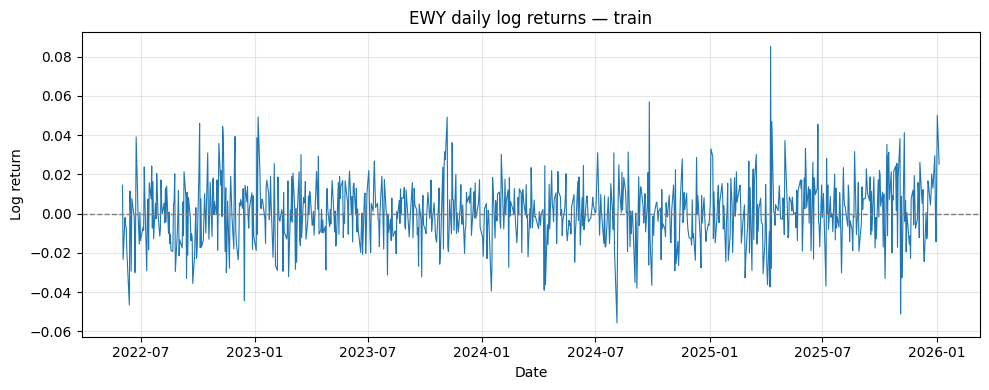

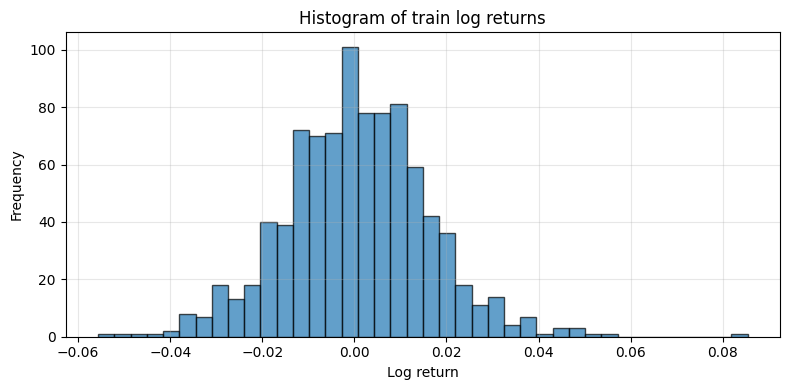

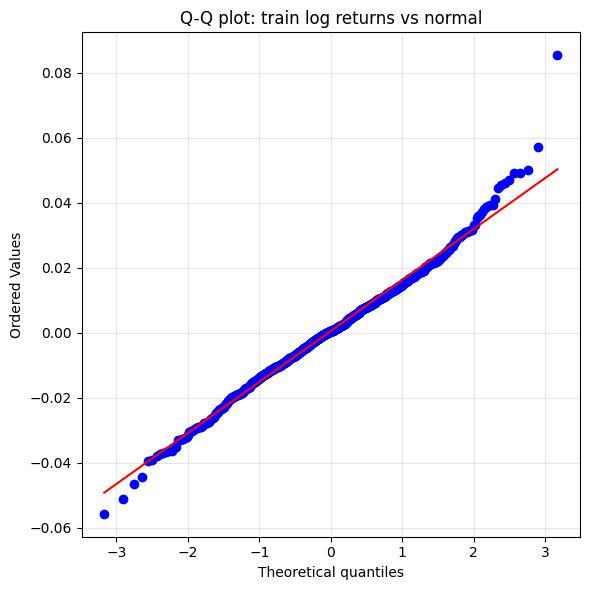

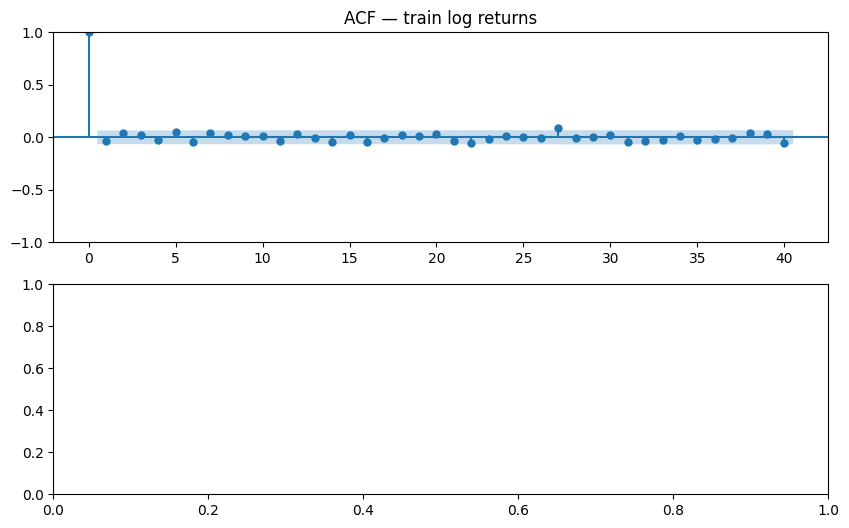

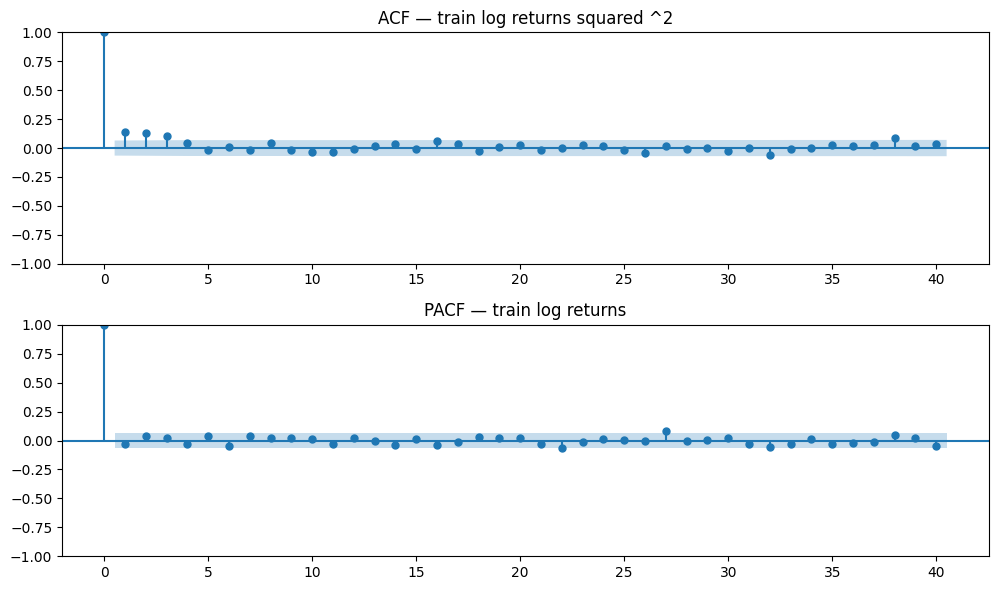

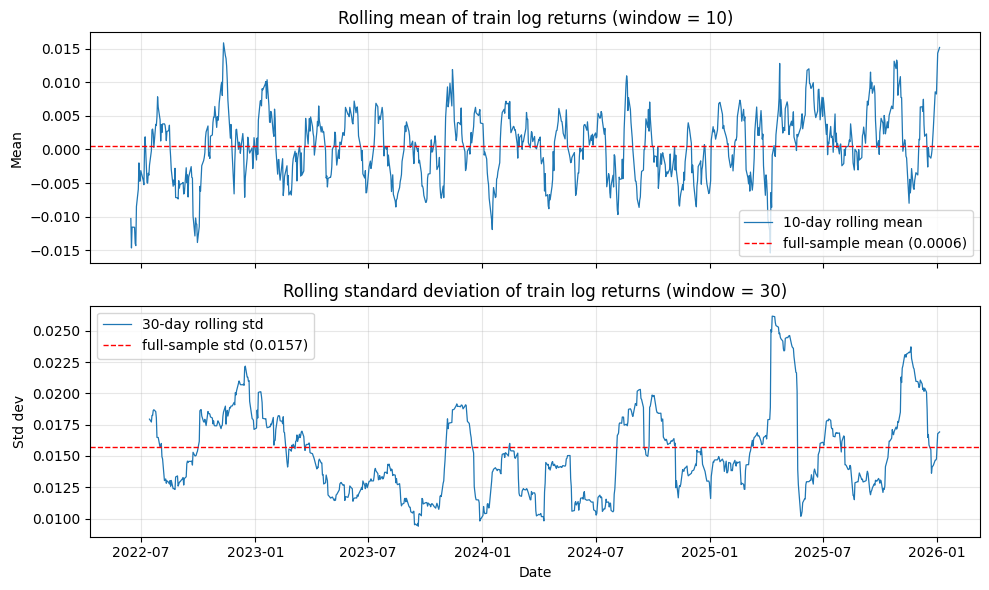

In [14]:
# Print graphs for: Log_r over time, Histogram, Q-Q plot, ACF, PACF

train_end = int(n * 0.9)
train_dates = returns_df['Date'].iloc[:train_end]
y_train = train_r.dropna()

# 1. Log returns over time
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_dates, y_train.values, linewidth=0.8)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('EWY daily log returns — train')
ax.set_xlabel('Date')
ax.set_ylabel('Log return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_train, bins=40, edgecolor='black', alpha=0.7)
ax.set_title('Histogram of train log returns')
ax.set_xlabel('Log return')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Q-Q plot vs normal
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(y_train, dist='norm', plot=ax)
ax.set_title('Q-Q plot: train log returns vs normal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(y_train, lags=40, ax=axes[0])
axes[0].set_title('ACF — train log returns')

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(y_train ** 2, lags=40, ax=axes[0])
axes[0].set_title('ACF — train log returns squared ^2')

plot_pacf(y_train, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF — train log returns')

plt.tight_layout()
plt.show()

# 5. Rolling mean and rolling std (with full-sample reference lines)
w = 30
roll_mean = y_train.rolling(w-20).mean()
roll_std = y_train.rolling(w).std()
avg_mean = y_train.mean()
avg_std = y_train.std()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(train_dates, roll_mean, linewidth=0.9, label=f'{w-20}-day rolling mean')
axes[0].axhline(avg_mean, color='red', linestyle='--', linewidth=1,
                 label=f'full-sample mean ({avg_mean:.4f})')
axes[0].set_title(f'Rolling mean of train log returns (window = {w-20})')
axes[0].set_ylabel('Mean')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_dates, roll_std, linewidth=0.9, label=f'{w}-day rolling std')
axes[1].axhline(avg_std, color='red', linestyle='--', linewidth=1,
                 label=f'full-sample std ({avg_std:.4f})')
axes[1].set_title(f'Rolling standard deviation of train log returns (window = {w})')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Std dev')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Fit simple ARMA mean + GARCH volatility grid

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

arma_orders = [(0, 0), (1, 0), (0, 1), (1, 1)]
garch_orders = [(1, 1), (1, 2), (2, 1)]

y_train = train_r.dropna() * 100
model_rows = []
fitted_models = {}

for ar_order, ma_order in arma_orders:
    for garch_p, garch_q in garch_orders:
        model_name = f'ARMA({ar_order},{ma_order}) + GARCH({garch_p},{garch_q})'
        key = (ar_order, ma_order, garch_p, garch_q)

        arma_fit = ARIMA(y_train, order=(ar_order, 0, ma_order)).fit()
        arma_resid = pd.Series(arma_fit.resid).dropna()

        garch_fit = arch_model(
            arma_resid,
            mean='Zero',
            vol='Garch',
            p=garch_p,
            q=garch_q,
            dist='t',
            rescale=False
        ).fit(disp='off')

        row = {
            'model': model_name,
            'arma_order': (ar_order, ma_order),
            'garch_order': (garch_p, garch_q),
            'AIC': arma_fit.aic + garch_fit.aic,
            'BIC': arma_fit.bic + garch_fit.bic,
            'MAE': np.mean(np.abs(arma_resid)),
            'arma_AIC': arma_fit.aic,
            'arma_BIC': arma_fit.bic,
            'garch_AIC': garch_fit.aic,
            'garch_BIC': garch_fit.bic,
        }

        for param_name, value in arma_fit.params.items():
            row[f'arma_{param_name}'] = value

        for param_name, value in garch_fit.params.items():
            row[f'garch_{param_name}'] = value

        model_rows.append(row)
        fitted_models[key] = {
            'arma_fit': arma_fit,
            'garch_fit': garch_fit,
            'model': model_name,
        }

model_results_df = pd.DataFrame(model_rows).sort_values('AIC').reset_index(drop=True)
display(model_results_df.round(4))

,model,arma_order,garch_order,AIC,BIC,MAE,arma_AIC,arma_BIC,garch_AIC,garch_BIC,arma_const,arma_sigma2,garch_omega,garch_alpha[1],garch_beta[1],garch_nu,garch_beta[2],garch_alpha[2],arma_ar.L1,arma_ma.L1
0,"ARMA(0,0) + GARCH(1,1)","(0, 0)","(1, 1)",6709.4583,6738.2794,1.2057,3378.0431,3387.6501,3331.4152,3350.6292,0.0580,2.4766,0.8216,0.1564,0.5111,12.8034,NaN,NaN,NaN,NaN
1,"ARMA(1,0) + GARCH(1,1)","(1, 0)","(1, 1)",6710.7024,6744.3269,1.2050,3379.1085,3393.5190,3331.5938,3350.8078,0.0579,2.4740,0.8062,0.1545,0.5192,12.9127,NaN,NaN,-0.0322,NaN
2,"ARMA(0,1) + GARCH(1,1)","(0, 1)","(1, 1)",6710.7254,6744.3499,1.2050,3379.1731,3393.5836,3331.5522,3350.7663,0.0579,2.4742,0.8068,0.1546,0.5188,12.9118,NaN,NaN,NaN,-0.0300
3,"ARMA(0,0) + GARCH(2,1)","(0, 0)","(2, 1)",6711.2390,6744.8636,1.2057,3378.0431,3387.6501,3333.1959,3357.2135,0.0580,2.4766,0.9227,0.1448,0.4523,12.7528,NaN,0.0295,NaN,NaN
4,"ARMA(0,0) + GARCH(1,2)","(0, 0)","(1, 2)",6711.4583,6745.0829,1.2057,3378.0431,3387.6501,3333.4152,3357.4327,0.0580,2.4766,0.8217,0.1564,0.5111,12.8020,0.0,NaN,NaN,NaN
5,"ARMA(1,1) + GARCH(1,1)","(1, 1)","(1, 1)",6712.4452,6750.8733,1.2048,3380.7608,3399.9748,3331.6845,3350.8985,0.0579,2.4731,0.8103,0.1540,0.5180,12.8384,NaN,NaN,-0.3039,0.2679
6,"ARMA(1,0) + GARCH(2,1)","(1, 0)","(2, 1)",6712.5187,6750.9467,1.2050,3379.1085,3393.5190,3333.4102,3357.4277,0.0579,2.4740,0.8984,0.1440,0.4656,12.8706,NaN,0.0267,-0.0322,NaN
7,"ARMA(0,1) + GARCH(2,1)","(0, 1)","(2, 1)",6712.5384,6750.9664,1.2050,3379.1731,3393.5836,3333.3653,3357.3828,0.0579,2.4742,0.8997,0.1440,0.4648,12.8657,NaN,0.0270,NaN,-0.0300
8,"ARMA(1,0) + GARCH(1,2)","(1, 0)","(1, 2)",6712.7024,6751.1304,1.2050,3379.1085,3393.5190,3333.5938,3357.6114,0.0579,2.4740,0.8062,0.1545,0.5192,12.9113,0.0,NaN,-0.0322,NaN
9,"ARMA(0,1) + GARCH(1,2)","(0, 1)","(1, 2)",6712.7254,6751.1534,1.2050,3379.1731,3393.5836,3333.5522,3357.5698,0.0579,2.4742,0.8068,0.1546,0.5188,12.9059,0.0,NaN,NaN,-0.0300


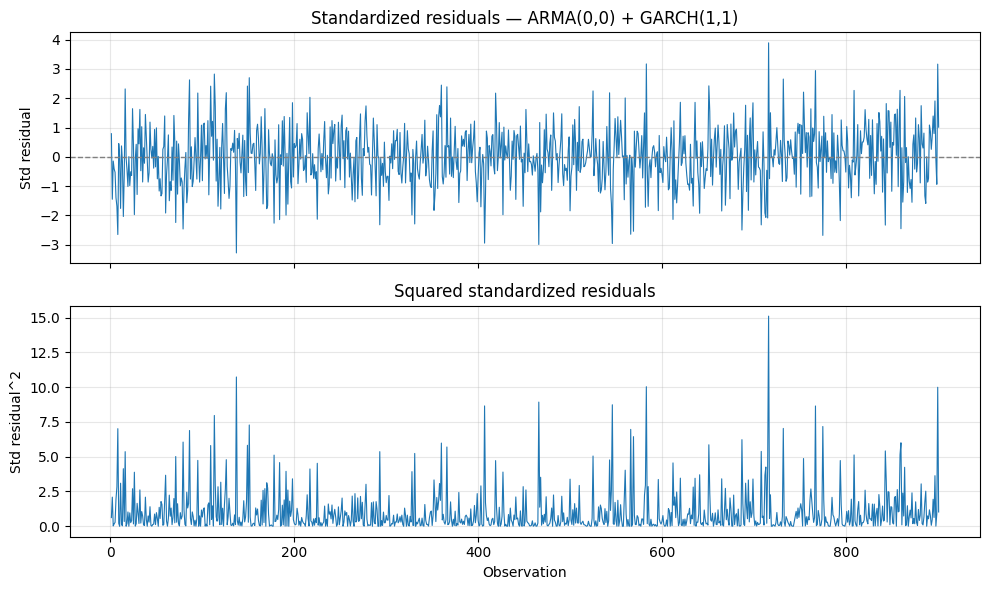

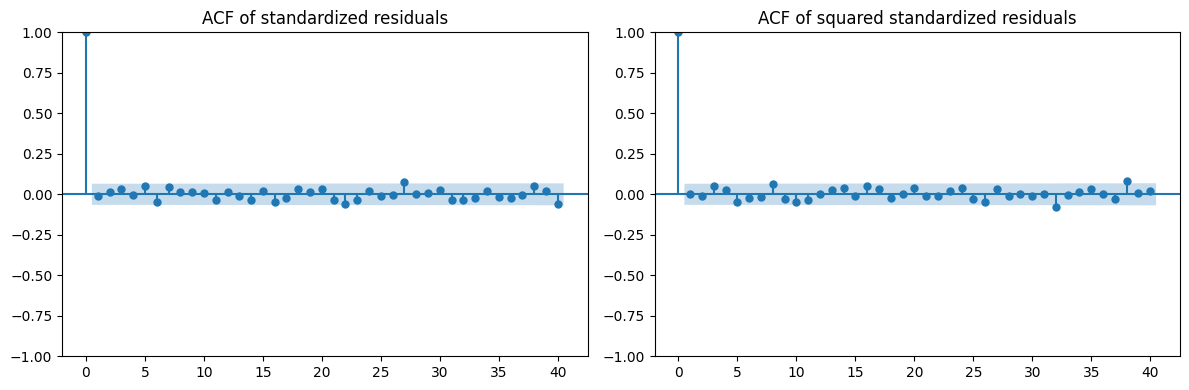

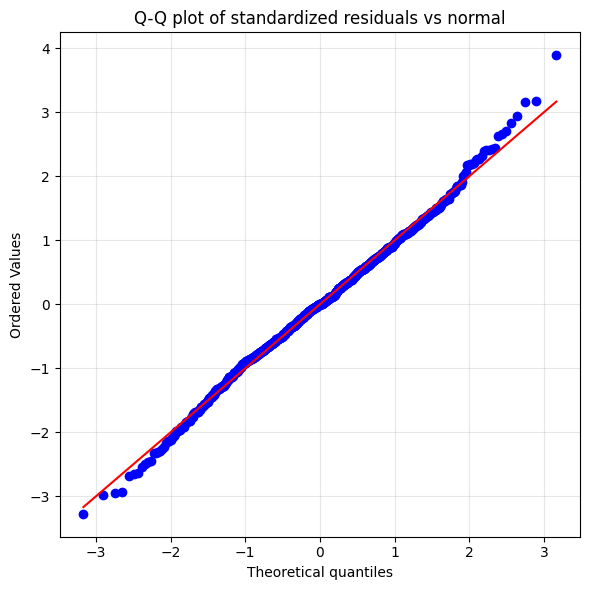

Ljung-Box test on standardized residuals:


,lb_stat,lb_pvalue
10,7.887692,0.639806
20,15.592806,0.741543


Ljung-Box test on squared standardized residuals:


,lb_stat,lb_pvalue
10,12.136185,0.276046
20,21.092993,0.391677


ARCH LM p-value, lag 10: 0.1936


In [15]:
# Residual diagnostics for best model: ARMA(0,0) + GARCH(1,1)

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

best_key = (0, 0, 1, 1)
best_model = fitted_models[best_key]
garch_fit = best_model['garch_fit']

std_resid = pd.Series(garch_fit.std_resid).dropna()
sq_std_resid = std_resid ** 2

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(std_resid.index, std_resid.values, linewidth=0.8)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Standardized residuals — ARMA(0,0) + GARCH(1,1)')
axes[0].set_ylabel('Std residual')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sq_std_resid.index, sq_std_resid.values, linewidth=0.8)
axes[1].set_title('Squared standardized residuals')
axes[1].set_xlabel('Observation')
axes[1].set_ylabel('Std residual^2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(std_resid, lags=40, ax=axes[0])
axes[0].set_title('ACF of standardized residuals')

plot_acf(sq_std_resid, lags=40, ax=axes[1])
axes[1].set_title('ACF of squared standardized residuals')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(std_resid, dist='norm', plot=ax)
ax.set_title('Q-Q plot of standardized residuals vs normal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

lb_resid = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)
lb_sq_resid = acorr_ljungbox(sq_std_resid, lags=[10, 20], return_df=True)
arch_lm_stat, arch_lm_pvalue, _, _ = het_arch(std_resid, nlags=10)

print('Ljung-Box test on standardized residuals:')
display(lb_resid)

print('Ljung-Box test on squared standardized residuals:')
display(lb_sq_resid)

print(f'ARCH LM p-value, lag 10: {arch_lm_pvalue:.4f}')

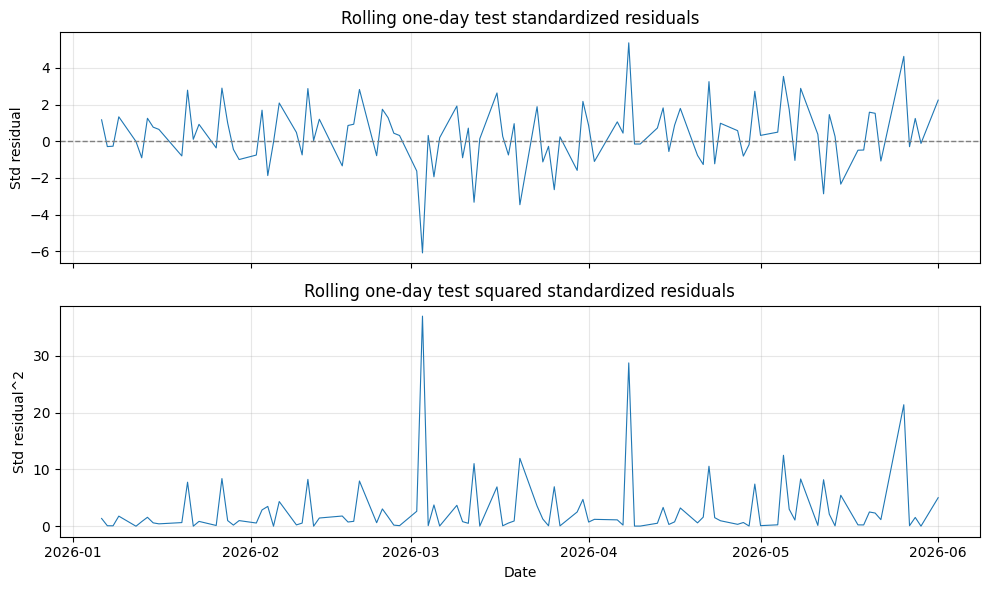

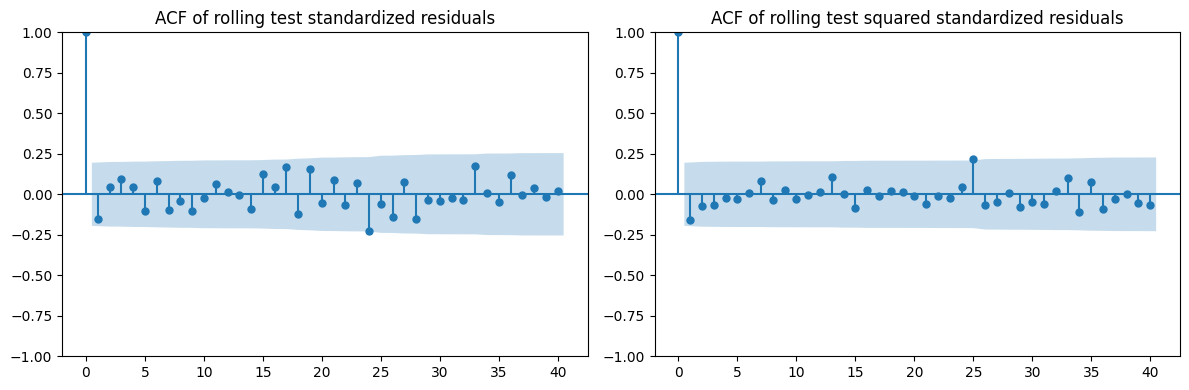

Ljung-Box test on rolling test standardized residuals:


,lb_stat,lb_pvalue
10,8.241670,0.605244
20,20.721248,0.413700


Ljung-Box test on rolling test squared standardized residuals:


,lb_stat,lb_pvalue
10,4.905818,0.89738
20,7.356813,0.99534


,Date,actual,mean_forecast,variance_forecast,residual,standardized_residual,squared_standardized_residual
0,2026-01-06,2.617359,0.058014,4.796927,2.559345,1.168550,1.365509
1,2026-01-07,-0.540441,0.058014,4.297824,-0.598455,-0.288674,0.083333
2,2026-01-08,-0.411947,0.058014,3.074288,-0.469961,-0.268034,0.071842
3,2026-01-09,2.134850,0.058014,2.427460,2.076836,1.332988,1.776856
4,2026-01-12,0.036728,0.058014,2.736911,-0.021286,-0.012867,0.000166


In [16]:
# One-day rolling-forward test diagnostics for ARMA(0,0) + GARCH(1,1)

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

best_key = (0, 0, 1, 1)
best_model = fitted_models[best_key]
arma_res = best_model['arma_fit']
garch_fit = best_model['garch_fit']

test_y = test_r.dropna() * 100
test_dates = returns_df.loc[test_y.index, 'Date']

omega = garch_fit.params['omega']
alpha = garch_fit.params['alpha[1]']
beta = garch_fit.params['beta[1]']

last_resid = pd.Series(arma_res.resid).dropna().iloc[-1]
last_sigma2 = (garch_fit.conditional_volatility ** 2).iloc[-1]

mean_forecasts = []
variance_forecasts = []
residuals = []
standardized_residuals = []

for actual in test_y:
    mean_forecast = float(np.asarray(arma_res.get_forecast(steps=1).predicted_mean).ravel()[0])
    sigma2_forecast = omega + alpha * last_resid ** 2 + beta * last_sigma2
    sigma2_forecast = max(sigma2_forecast, 1e-12)

    resid = actual - mean_forecast
    std_resid = resid / np.sqrt(sigma2_forecast)

    mean_forecasts.append(mean_forecast)
    variance_forecasts.append(sigma2_forecast)
    residuals.append(resid)
    standardized_residuals.append(std_resid)

    last_resid = resid
    last_sigma2 = sigma2_forecast
    arma_res = arma_res.append([actual], refit=False)

rolling_test_df = pd.DataFrame({
    'Date': test_dates.values,
    'actual': test_y.values,
    'mean_forecast': mean_forecasts,
    'variance_forecast': variance_forecasts,
    'residual': residuals,
    'standardized_residual': standardized_residuals,
})
rolling_test_df['squared_standardized_residual'] = rolling_test_df['standardized_residual'] ** 2

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(rolling_test_df['Date'], rolling_test_df['standardized_residual'], linewidth=0.8)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Rolling one-day test standardized residuals')
axes[0].set_ylabel('Std residual')
axes[0].grid(True, alpha=0.3)

axes[1].plot(rolling_test_df['Date'], rolling_test_df['squared_standardized_residual'], linewidth=0.8)
axes[1].set_title('Rolling one-day test squared standardized residuals')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Std residual^2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(rolling_test_df['standardized_residual'], lags=40, ax=axes[0])
axes[0].set_title('ACF of rolling test standardized residuals')

plot_acf(rolling_test_df['squared_standardized_residual'], lags=40, ax=axes[1])
axes[1].set_title('ACF of rolling test squared standardized residuals')

plt.tight_layout()
plt.show()

lb_resid = acorr_ljungbox(rolling_test_df['standardized_residual'], lags=[10, 20], return_df=True)
lb_sq_resid = acorr_ljungbox(rolling_test_df['squared_standardized_residual'], lags=[10, 20], return_df=True)

print('Ljung-Box test on rolling test standardized residuals:')
display(lb_resid)

print('Ljung-Box test on rolling test squared standardized residuals:')
display(lb_sq_resid)

display(rolling_test_df.head())